# 17. Редкий класс (1%): метрики, веса классов, порог и бюджет

| | |
|---|---|
| **Уровень** | 3 из 4 — средние данные: полный цикл и типовые случаи (`3_medium`) |
| **Скрипт-источник** | [`17_imbalanced_classes.py`](../17_imbalanced_classes.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 4 с |

**Цель.** Правильно работать с сильно несбалансированной классификацией.

### Чему вы научитесь

- Почему точность бесполезна
- ROC AUC против средней точности (AP)
- Ловушка ранней остановки у взвешенной модели
- `scale_pos_weight` и что он делает с вероятностями
- Выбор порога по бюджету («обзвонить 2% клиентов»)
- Пересчёт вероятностей

### Данные

`_data.make_customers` — 100 000 клиентов, откликнулся 1%.

### План

1. **Этап 1.** Данные
2. **Этап 2.** Ловушка: ранняя остановка по log-loss у модели с весами
3. **Этап 3.** Честное сравнение: остановка по средней точности (AP)
4. **Этап 4.** Порог по бюджету: обзвонить 2% клиентов с наибольшей вероятностью
5. **Этап 5.** Вернуть вероятностям смысл: пересчёт p' = p / (p + w(1 − p)) для модели с весом w = 99

> Ноутбук собран из `examples/3_medium/17_imbalanced_classes.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example
from _data import make_customers

ex = Example(EXAMPLES / "3_medium/17_imbalanced_classes.py", title="17. Редкий класс: метрики, веса, порог",
             goal="работать с классом в 1% правильно")

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
from gbcourse.style import ROLE
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

## Этап 1. Данные

In [2]:
X, y = make_customers(ex.size(100_000, 30_000), positive_rate=0.01, seed=17)
ex.describe(X, y, target="отклик", task="classification", source="examples/_data.py → make_customers(positive_rate=0.01)")
X_tmp, X_te, y_tmp, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
X_tr, X_va, y_tr, y_va = train_test_split(X_tmp, y_tmp, test_size=0.3, stratify=y_tmp, random_state=0)
print(f"   откликов: обучение {y_tr.sum()}, валидация {y_va.sum()}, тест {y_te.sum()}")
print(f"   точность модели «никто не откликнется»: {accuracy_score(y_te, np.zeros_like(y_te)):.3f}")


def fit(weight, metric="average_precision"):
    """Ранняя остановка ТОЛЬКО по указанной метрике на валидации."""
    m = lgb.LGBMClassifier(n_estimators=3000, learning_rate=0.03, num_leaves=15, min_child_samples=100,
                           scale_pos_weight=weight, metric=metric, verbose=-1, random_state=0)
    m.fit(X_tr, y_tr, eval_X=(X_va,), eval_y=(y_va,), callbacks=[lgb.early_stopping(200, verbose=False)])
    return m, m.predict_proba(X_te)[:, 1]


def report(name, m, p):
    print(f"   {name:22s} деревьев {m.best_iteration_:4d}; AUC {roc_auc_score(y_te, p):.4f}, AP {average_precision_score(y_te, p):.4f}, "
          f"log-loss {log_loss(y_te, p):.4f}, средний прогноз {p.mean():.4f}")

   Источник: examples/_data.py → make_customers(positive_rate=0.01)
   Объектов: 100 000   признаков: 8   память: 4.77 МБ
   Типы признаков: float64 × 3, int64 × 3, category × 2
   Пропуски: доход 8.0%
   Цель «отклик»: класс 0 — 98989 (99.0%), класс 1 — 1011 (1.0%)
   Первые строки:


,возраст,доход,стаж_мес,покупок,дней_с_покупки,канал,регион,подписка,[отклик]
0,53.0,46250.0,116,13,8.0,сайт,25,1,0
1,44.0,81743.0,119,9,7.0,приложение,25,0,0
2,34.0,NaN,59,6,30.0,партнёр,27,1,0


   откликов: обучение 496, валидация 212, тест 303
   точность модели «никто не откликнется»: 0.990


## Этап 2. Ловушка: ранняя остановка по log-loss у модели с весами

In [3]:
m_trap, p_trap = fit(99.0, metric="binary_logloss")
report("вес 99, стоп по log-loss", m_trap, p_trap)
ex.note("""Вес 99 раздувает вероятности, и log-loss на валидации (без весов) с первых деревьев только растёт —
остановка срабатывает почти сразу, модель остаётся недообученной. Со взвешенной моделью останавливайтесь по метрике
ранжирования (AP, AUC) — или по log-loss с теми же весами на валидации.""")
assert m_trap.best_iteration_ < 10

   вес 99, стоп по log-loss деревьев    1; AUC 0.6538, AP 0.0180, log-loss 0.0710, средний прогноз 0.0388

> ▸ **Вывод.** Вес 99 раздувает вероятности, и log-loss на валидации (без весов) с первых деревьев только растёт — остановка срабатывает почти сразу, модель остаётся недообученной. Со взвешенной моделью останавливайтесь по метрике ранжирования (AP, AUC) — или по log-loss с теми же весами на валидации.

## Этап 3. Честное сравнение: остановка по средней точности (AP)

In [4]:
print(f"   доля откликов на тесте: {y_te.mean():.4f}")
m0, p0 = fit(1.0)
m5, p5 = fit(5.0)
m1, p1 = fit(99.0)
report("без весов", m0, p0)
report("scale_pos_weight = 5", m5, p5)
report("scale_pos_weight = 99", m1, p1)
ex.note("""Веса почти не меняют ранжирование: различия AUC и AP — в пределах случайного разброса (проверено на
нескольких seed; при ~300 откликах в тесте разброс AUC около ±0.015). Зато вероятности раздуваются: средний
прогноз с весом 99 в десятки раз больше доли откликов.""")
if not ex.quick:                                              # на уменьшенных данных откликов слишком мало
    assert p1.mean() > 10 * y_te.mean() and abs(p0.mean() - y_te.mean()) < 0.003

   доля откликов на тесте: 0.0101


   без весов              деревьев  135; AUC 0.7062, AP 0.0308, log-loss 0.0538, средний прогноз 0.0101
   scale_pos_weight = 5   деревьев  117; AUC 0.7066, AP 0.0314, log-loss 0.0723, средний прогноз 0.0415
   scale_pos_weight = 99  деревьев  113; AUC 0.6906, AP 0.0276, log-loss 0.3987, средний прогноз 0.2796


> ▸ **Вывод.** Веса почти не меняют ранжирование: различия AUC и AP — в пределах случайного разброса (проверено на нескольких seed; при ~300 откликах в тесте разброс AUC около ±0.015). Зато вероятности раздуваются: средний прогноз с весом 99 в десятки раз больше доли откликов.

## Этап 4. Порог по бюджету: обзвонить 2% клиентов с наибольшей вероятностью

   без весов : в топ-2% (600 клиентов) — 29 откликов из 303 (охват 10%; случайный выбор дал бы ~2%)
   вес 5     : в топ-2% (600 клиентов) — 28 откликов из 303 (охват 9%; случайный выбор дал бы ~2%)
   вес 99    : в топ-2% (600 клиентов) — 24 откликов из 303 (охват 8%; случайный выбор дал бы ~2%)


> ▸ **Вывод.** Бюджет задаёт не порог вероятности, а число объектов сверху списка — важно только ранжирование.

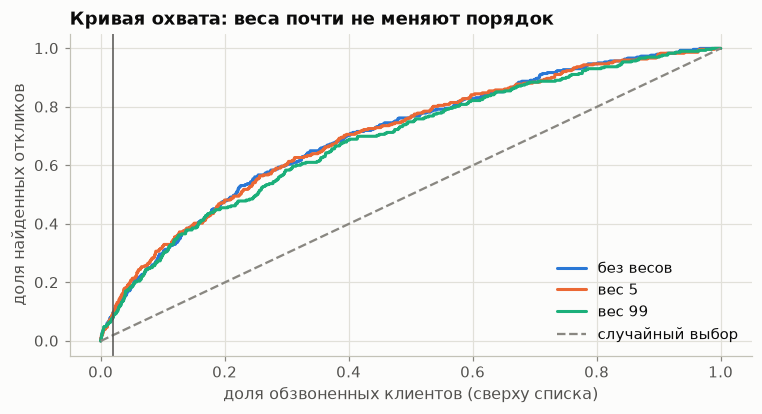

In [5]:
k = int(0.02 * len(y_te))
for name, p in (("без весов", p0), ("вес 5", p5), ("вес 99", p1)):
    top = np.argsort(-p)[:k]
    print(f"   {name:10s}: в топ-2% ({k} клиентов) — {y_te[top].sum()} откликов из {y_te.sum()} "
          f"(охват {y_te[top].sum() / y_te.sum():.0%}; случайный выбор дал бы ~2%)")
ex.note("Бюджет задаёт не порог вероятности, а число объектов сверху списка — важно только ранжирование.")
fig, ax = plt.subplots(figsize=(8, 3.8))
share = np.arange(1, len(y_te) + 1) / len(y_te)
for (name, p), c in zip((("без весов", p0), ("вес 5", p5), ("вес 99", p1)), (ROLE["model"], ROLE["tree"], ROLE["test"])):
    ax.plot(share, np.cumsum(y_te[np.argsort(-p)]) / y_te.sum(), color=c, lw=2, label=name)
ax.plot([0, 1], [0, 1], color=ROLE["truth"], ls="--", lw=1.5, label="случайный выбор")
ax.axvline(0.02, color=ROLE["data"], lw=1)
ax.set(xlabel="доля обзвоненных клиентов (сверху списка)", ylabel="доля найденных откликов",
       title="Кривая охвата: веса почти не меняют порядок")
ax.legend()
ex.finish(fig, "17_gains")

## Этап 5. Вернуть вероятностям смысл: пересчёт p' = p / (p + w(1 − p)) для модели с весом w = 99

In [6]:
pc = p1 / (p1 + 99.0 * (1 - p1))
report("вес 99, пересчёт", m1, pc)
ex.note("""Пересчёт возвращает вероятности к правильному масштабу (средний прогноз снова близок к доле откликов, а не к 0.28),
порядок при этом не меняется. Точным он был бы для модели, дошедшей до оптимума взвешенной потери; ранняя остановка
и сжатие оставляют погрешность, поэтому надёжнее калибровать на валидации (пример 28).
Практическое правило: при редком классе веса не обязательны — обучайте без них, а порог выбирайте по бюджету.""")
ex.done()

   вес 99, пересчёт       деревьев  113; AUC 0.6906, AP 0.0276, log-loss 0.0568, средний прогноз 0.0062


> ▸ **Вывод.** Пересчёт возвращает вероятности к правильному масштабу (средний прогноз снова близок к доле откликов, а не к 0.28), порядок при этом не меняется. Точным он был бы для модели, дошедшей до оптимума взвешенной потери; ранняя остановка и сжатие оставляют погрешность, поэтому надёжнее калибровать на валидации (пример 28). Практическое правило: при редком классе веса не обязательны — обучайте без них, а порог выбирайте по бюджету.

Готово за 2.3 с


## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Остановите модель с весом 99 по log-loss с теми же весами на валидации (`eval_sample_weight`) — сколько будет деревьев?
2. Возьмите бюджет обзвона 5% вместо 2% и сравните охват моделей.
3. Откалибруйте модель с весом 99 изотонической регрессией (пример 28) и сравните с пересчётом по формуле.

## Что дальше

- **Теория в курсе:** [10.2 «Пропуски, выбросы, дисбаланс»](../../../lessons/lesson_10_2/README.md), [13.2 «Калибровка и интервалы»](../../../lessons/lesson_13_2/README.md).
- **Предыдущий пример:** [16. Пропуски: три механизма и четыре способа обработки](16_missing_values.ipynb)
- **Следующий пример:** [18. Своя функция потерь и своя метрика: недооценка в 3 раза дороже переоценки](18_custom_loss_and_metric.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)